# From Questions to Data: Exploring Ourselves as a Dataset

Welcome! In this activity, we will turn a real-world question into a data question, collect our own data, explore it visually, and start thinking about samples vs. populations, bias, simulation, and even a tiny preview of inference.

*No statistics equations quite yet — just thinking like a data scientist using curiosity, exploration, and simulation.* 

## Scenario
The Student Union wants to organise a movie night for the department.
They ask:
* **"How many people will actually show up?"**
* And: **"Are physics students less enthusiastic about movies than other departments?"**

To make decisions (room size, budget, snacks), they need data-based expectations, not just guesses.

## Warm-Up Discussion 

**Discuss in teams of 2-3 people**:

* What information would you need to estimate how many people might attend?
* What could be measured?
* Who is the population? Who do we actually observe?
* What biases might appear in using just our class as data?

Write your thoughts below:

<Space for your thoughts>

## Collect Our Class Data

We’ll enter two pieces of data per student:

* `movies_per_month`: How many movies did you watch last month (December)?
* `will_attend_movie_night`: Would you personally attend a student union movie night? (1 = Yes, 0 = No)

**ADD LINK TO WOOCLAP POLL**

In [9]:
import pandas as pd

# number of students: adjust as needed!
n = 50

# Template — fill in or paste values here.
data = pd.DataFrame({
    "student_id": range(1, n+1),  # adjust size n as needed
    "movies_per_month": [None]*n,   # FILL IN MOVIES PER MONTH HERE
    "will_attend_movie_night": [None]*n # FILL IN MOVIE ATTENDANCE HERE
})

# show first few rows of table
data.head()


,student_id,movies_per_month,will_attend_movie_night
0,1,None,None
1,2,None,None
2,3,None,None
3,4,None,None
4,5,None,None


**Task**: Fill in your class values above OR simulate them below for testing (optional).

In [11]:
import numpy as np

# Uncomment to simulate fake class data (for demonstration or testing)
data['movies_per_month'] = np.random.poisson(lam=3, size=len(data))
data['will_attend_movie_night'] = (data['movies_per_month'] > 2).astype(int)

data.head()

,student_id,movies_per_month,will_attend_movie_night
0,1,2,0
1,2,2,0
2,3,4,1
3,4,4,1
4,5,3,1


In [13]:
len(data)

50

## Exploratory Data Analysis
First question: What does our class look like in terms of movie-watching? What kind of representation(s) would be helpful in figuring this out?

**Solution**:
* plot histogram
* compute mean and variance
* look for outliers

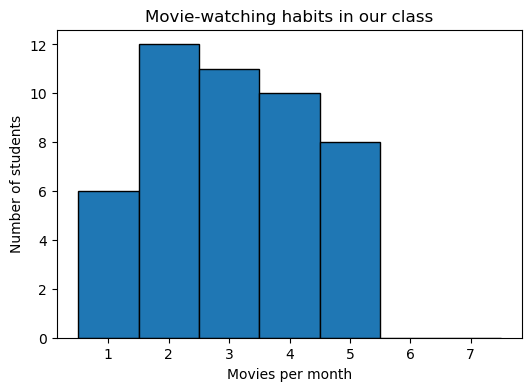

In [23]:
import matplotlib.pyplot as plt

# Make sure types are numeric
data['movies_per_month'] = data['movies_per_month'].astype(float)
data['will_attend_movie_night'] = data['will_attend_movie_night'].astype(float)

# plot a histogram of the movies per month
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.hist(data['movies_per_month'], bins=np.arange(0.5, 8.5, 1), edgecolor='black')
ax.set_xlabel("Movies per month")
ax.set_ylabel("Number of students")
ax.set_title("Movie-watching habits in our class")
plt.show()

### Side Note: Tukey's 5-Number Summary

Statistician John Tukey came up with a 5-number summary that can describe samples like the one we collected above. It includes the following five summaries of the data:
* the sample minimum (the smallest observation)
* the lower/first quartile (the point below which 25% of the data points fall)
* the median (the point below which 50% of the data points fall)
* the upper quartile (the point below which 75% of the data points fall)
* the sample maximum (the largest observation)

In `pandas`, you can access it using the `describe()` method:

In [18]:
data.describe()

,student_id,movies_per_month,will_attend_movie_night
count,50.00000,50.000000,50.000000
mean,25.50000,2.860000,0.580000
std,14.57738,1.457003,0.498569
min,1.00000,0.000000,0.000000
25%,13.25000,2.000000,0.000000
50%,25.50000,3.000000,1.000000
75%,37.75000,4.000000,1.000000
max,50.00000,5.000000,1.000000


**Question**: In the summary above, the quartiles are all at integer numbers. Is this something you'd expect? Why or why not?

**Reflection Questions**
* Is the class mostly low movie watchers, or are there some outliers?
* What does the mean represent here? Does it describe a “typical” student?
* If one person watches 20 movies/month, what happens to the mean? Why does that matter?

## Compare to a Hypothetical Population
Let’s imagine a simulated student population in the Media Studies degree.

We don’t have their data — but we simulate based on the Student Union’s stereotype that "media studies students love movies".

**Important idea**: We can simulate a population to compare to a sample.

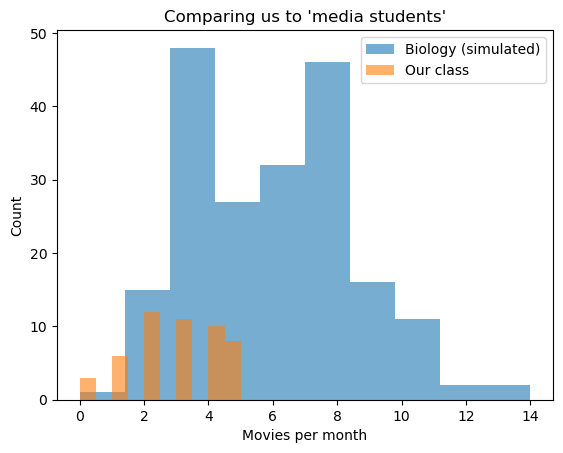

In [19]:
# Simulated media studies population

lam = 6 # average number of movies per month for the media studies students: adustable!

# draw number of movies for media students from a Poisson distribution
media_students = pd.DataFrame({
    "movies_per_month": np.random.poisson(lam=lam, size=200)
})

plt.hist(media_students['movies_per_month'], alpha=0.6, label="Biology (simulated)")
plt.hist(data['movies_per_month'], alpha=0.6, label="Our class")
plt.legend()
plt.xlabel("Movies per month")
plt.ylabel("Count")
plt.title("Comparing us to 'media students'")
plt.show()


** Question**: What do you notice in this histogram about the two populations? Specifically, consider the widths and heights of the bins.

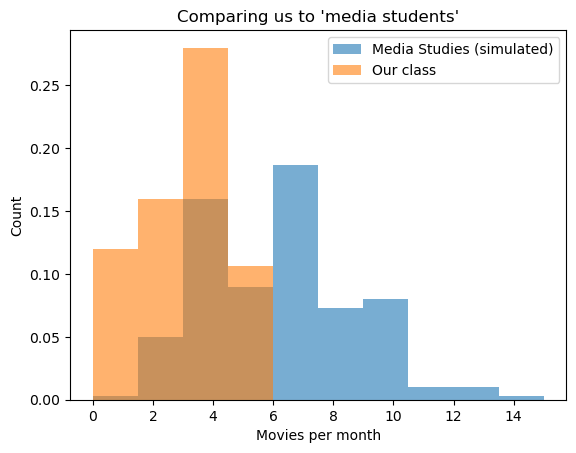

In [20]:
plt.hist(media_students['movies_per_month'], alpha=0.6, range=[0,15], 
         label="Media Studies (simulated)", density=True)
plt.hist(data['movies_per_month'], alpha=0.6, label="Our class", range=[0,15], density=True)
plt.legend()
plt.xlabel("Movies per month")
plt.ylabel("Count")
plt.title("Comparing us to 'media students'")
plt.show()


**Discussion Prompt**
* Does our class look different from the biology population?
* If yes — is that evidence, or just a result of small sample randomness?
* What assumptions went into the media studies simulation? How could that influence our conclusion?

## Prediction: Do More Movies = More Attendance?

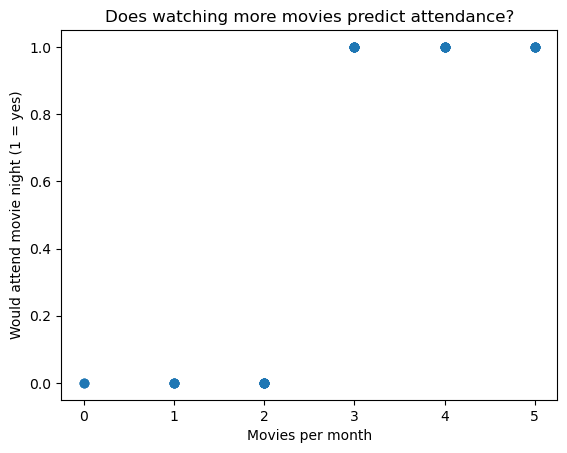

In [21]:
plt.scatter(data['movies_per_month'], data['will_attend_movie_night'])
plt.xlabel("Movies per month")
plt.ylabel("Would attend movie night (1 = yes)")
plt.title("Does watching more movies predict attendance?")
plt.show()

**Questions**
* Do you see a pattern or cluster?
* Could we draw a line or threshold by eye?
* We're already thinking like modelers — without writing anything like a formula!

## Simulation Preview of Hypothesis Testing
Imagine we take many random samples from the media studies population that are the same size as our class.
Where does our class mean fall compared to those samples?

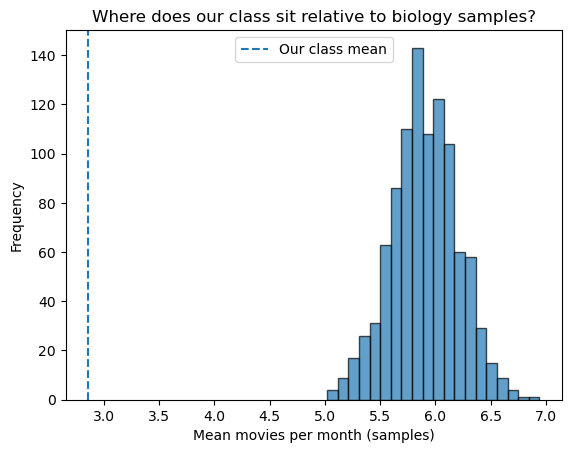

In [22]:
# Compare class mean with simulated sample means from biology students
sample_means = []
for _ in range(1000):
    sample = np.random.choice(media_students['movies_per_month'], size=len(data), replace=False)
    sample_means.append(sample.mean())

plt.hist(sample_means, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(data['movies_per_month'].mean(), linestyle='--', label="Our class mean")
plt.xlabel("Mean movies per month (samples)")
plt.ylabel("Frequency")
plt.title("Where does our class sit relative to biology samples?")
plt.legend()
plt.show()

## Big Takeaway

You just did a simulation-based hypothesis test, even though we never used any statistics words.

What we’ve done today:
* Turned a question into data
* Explored the data visually
* Thought about samples vs populations
* Used simulation to reason about difference
* Started thinking like statisticians